In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import asyncio
import ipywidgets as widgets
from IPython.display import display


from scipy.optimize import least_squares
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import simpson
from scipy.interpolate import PchipInterpolator
from scipy.special import voigt_profile

In [94]:


# ------------------------------------------------------------
# Specify the spectrum to analyze
# ------------------------------------------------------------

input_file = "AR150.csv"      # <-- Change this filename

# ------------------------------------------------------------
# Read CSV
# ------------------------------------------------------------

df = pd.read_csv(input_file)

base_name = Path(input_file).stem

# ------------------------------------------------------------
# First two columns must be:
# Binding Energy, Intensity
# ------------------------------------------------------------

x_original = df.iloc[:, 4].to_numpy(dtype=float)
y_original = df.iloc[:, 5].to_numpy(dtype=float)

print(f"\nLoaded: {input_file}")
print(f"Spectrum: {base_name}")
print(f"Points: {len(df)}")
print(
    f"Binding Energy Range: "
    f"{x_original.min():.3f} – "
    f"{x_original.max():.3f} eV"
)


Loaded: AR150.csv
Spectrum: AR150
Points: 201
Binding Energy Range: 15.500 – 35.500 eV


# GENERATE SHIRLEY BACKGROUND


In [95]:
# ============================================================
# CELL 1: AUTOMATIC SHIRLEY WINDOW
# ============================================================

def auto_shirley_window(
    x,
    y,
    smooth_sigma=2.0,
    edge_fraction=0.10,
    threshold_fraction=0.02,
    padding_fraction=0.04,
):
    """
    Automatically determine a Shirley analysis window from the spectrum.

    Logic:
    1. Sort by increasing binding energy.
    2. Smooth the spectrum to suppress point-to-point noise.
    3. Estimate a simple line between the outer baseline regions.
    4. Detect where the measured spectrum rises significantly above that line.
    5. Add a small amount of padding to place the Shirley endpoints
       outside the detected spectral envelope.

    This procedure is element-independent.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    # Sort low BE -> high BE for numerical work
    order = np.argsort(x)
    xs = x[order]
    ys = y[order]

    n = len(xs)

    if n < 20:
        raise ValueError(
            "Spectrum contains too few points for automatic Shirley selection."
        )

    # --------------------------------------------------------
    # Smooth only for window detection
    # --------------------------------------------------------

    y_smooth = gaussian_filter1d(
        ys,
        sigma=smooth_sigma,
    )

    # --------------------------------------------------------
    # Estimate the broad outer baseline
    # --------------------------------------------------------

    n_edge = max(
        5,
        int(round(edge_fraction * n)),
    )

    low_level = np.median(
        y_smooth[:n_edge]
    )

    high_level = np.median(
        y_smooth[-n_edge:]
    )

    rough_baseline = np.linspace(
        low_level,
        high_level,
        n,
    )

    signal_above_baseline = (
        y_smooth - rough_baseline
    )

    positive_signal = np.maximum(
        signal_above_baseline,
        0.0,
    )

    signal_scale = np.max(
        positive_signal
    )

    if not np.isfinite(signal_scale) or signal_scale <= 0:
        raise RuntimeError(
            "Could not identify a spectral envelope."
        )

    # --------------------------------------------------------
    # Locate significant spectral intensity
    # --------------------------------------------------------

    threshold = (
        threshold_fraction
        * signal_scale
    )

    active = np.flatnonzero(
        positive_signal > threshold
    )

    if len(active) == 0:
        raise RuntimeError(
            "No significant spectral region was detected."
        )

    # --------------------------------------------------------
    # Add padding so endpoints sit outside the peak envelope
    # --------------------------------------------------------

    pad = max(
        2,
        int(round(padding_fraction * n)),
    )

    first = max(
        0,
        active[0] - pad,
    )

    last = min(
        n - 1,
        active[-1] + pad,
    )

    SHIRLEY_MIN_BE = float(
        xs[first]
    )

    SHIRLEY_MAX_BE = float(
        xs[last]
    )

    print("\nAUTOMATIC SHIRLEY WINDOW")
    print(
        f"Low-BE endpoint  = {SHIRLEY_MIN_BE:.3f} eV"
    )
    print(
        f"High-BE endpoint = {SHIRLEY_MAX_BE:.3f} eV"
    )

    return SHIRLEY_MIN_BE, SHIRLEY_MAX_BE


SHIRLEY_MIN_BE, SHIRLEY_MAX_BE = auto_shirley_window(
    x_original,
    y_original,
)


AUTOMATIC SHIRLEY WINDOW
Low-BE endpoint  = 20.200 eV
High-BE endpoint = 34.900 eV


Shirley converged after 7 iterations.


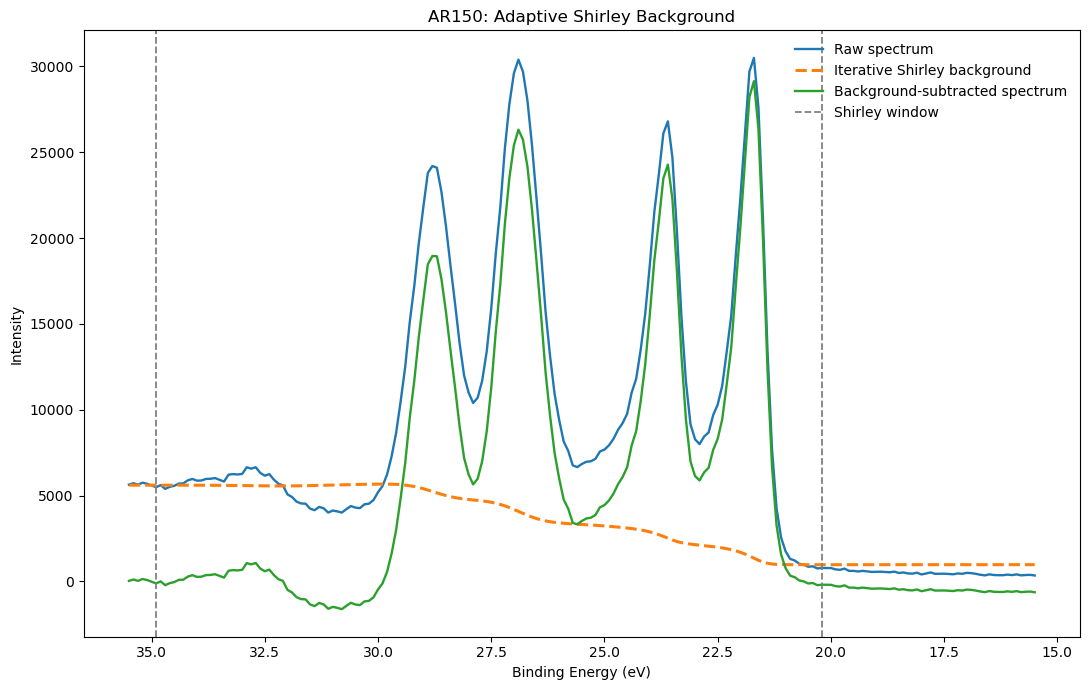

In [96]:
# ============================================================
# CELL 2: ITERATIVE SHIRLEY BACKGROUND
# ============================================================

def shirley_background(
    x,
    y,
    fit_min,
    fit_max,
    endpoint_points=8,
    max_iter=1000,
    tol=1e-8,
):
    """
    Calculate an iterative Shirley background between two endpoints.

    The endpoint intensities are averaged over several points for
    noise robustness.

    Outside the selected Shirley window, the background is held
    constant at the corresponding endpoint level.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)

    x_valid = x[valid]
    y_valid = y[valid]

    # Sort in increasing binding energy
    order = np.argsort(x_valid)

    xs = x_valid[order]
    ys = y_valid[order]

    # --------------------------------------------------------
    # Select Shirley region
    # --------------------------------------------------------

    window_mask = (
        (xs >= fit_min)
        & (xs <= fit_max)
    )

    xw = xs[window_mask]
    yw = ys[window_mask]

    if len(xw) < 2 * endpoint_points + 5:
        raise ValueError(
            "Selected Shirley window is too small."
        )

    n_ep = min(
        endpoint_points,
        len(xw) // 4,
    )

    # Average endpoint intensities to reduce noise
    y_low_be = float(
        np.mean(yw[:n_ep])
    )

    y_high_be = float(
        np.mean(yw[-n_ep:])
    )

    # --------------------------------------------------------
    # Initial background
    # --------------------------------------------------------

    background = np.linspace(
        y_low_be,
        y_high_be,
        len(xw),
    )

    # --------------------------------------------------------
    # Iterative Shirley calculation
    # --------------------------------------------------------

    for iteration in range(max_iter):

        previous = background.copy()

        # Intensity remaining above current background
        corrected = (
            yw - previous
        )

        # Numerical cumulative integral from high BE -> low BE
        dx = np.diff(xw)

        segment_area = (
            0.5
            * (
                corrected[:-1]
                + corrected[1:]
            )
            * dx
        )

        cumulative = np.zeros_like(xw)

        cumulative[:-1] = np.cumsum(
            segment_area[::-1]
        )[::-1]

        total_area = cumulative[0]

        if (
            not np.isfinite(total_area)
            or abs(total_area) < 1e-20
        ):
            raise RuntimeError(
                "Shirley iteration encountered zero integrated intensity."
            )

        # Normalized Shirley integral
        fraction = (
            cumulative
            / total_area
        )

        background = (
            y_high_be
            + (
                y_low_be
                - y_high_be
            )
            * fraction
        )

        # Exact endpoint values
        background[0] = y_low_be
        background[-1] = y_high_be

        change = np.max(
            np.abs(
                background - previous
            )
        )

        scale = max(
            np.max(np.abs(background)),
            1.0,
        )

        if change / scale < tol:
            print(
                f"Shirley converged after "
                f"{iteration + 1} iterations."
            )
            break

    else:
        print(
            "Warning: Shirley background reached "
            "the maximum iteration count."
        )

    # --------------------------------------------------------
    # Construct background across entire original spectrum
    # --------------------------------------------------------

    full_background_sorted = np.empty_like(
        ys,
        dtype=float,
    )

    below = xs < fit_min
    inside = window_mask
    above = xs > fit_max

    full_background_sorted[below] = y_low_be
    full_background_sorted[inside] = background
    full_background_sorted[above] = y_high_be

    # Return to original ordering
    full_background_valid = np.empty_like(
        full_background_sorted
    )

    full_background_valid[order] = (
        full_background_sorted
    )

    full_background = np.full_like(
        x,
        np.nan,
        dtype=float,
    )

    full_background[valid] = (
        full_background_valid
    )

    return full_background


# ------------------------------------------------------------
# Calculate background and corrected spectrum
# ------------------------------------------------------------

shirley = shirley_background(
    x_original,
    y_original,
    fit_min=SHIRLEY_MIN_BE,
    fit_max=SHIRLEY_MAX_BE,
    endpoint_points=8,
)

corrected = (
    y_original - shirley
)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.plot(
    x_original,
    y_original,
    color="tab:blue",
    linewidth=1.7,
    label="Raw spectrum",
)

plt.plot(
    x_original,
    shirley,
    color="tab:orange",
    linestyle="--",
    linewidth=2.2,
    label="Iterative Shirley background",
)

plt.plot(
    x_original,
    corrected,
    color="tab:green",
    linewidth=1.7,
    label="Background-subtracted spectrum",
)

plt.axvline(
    SHIRLEY_MIN_BE,
    color="gray",
    linestyle="--",
    linewidth=1.3,
    label="Shirley window",
)

plt.axvline(
    SHIRLEY_MAX_BE,
    color="gray",
    linestyle="--",
    linewidth=1.3,
)

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.title(
    f"{base_name}: Adaptive Shirley Background"
)

plt.gca().invert_xaxis()

plt.legend(
    frameon=False,
)

plt.tight_layout()
plt.show()

In [97]:
# Only divide by transmission if Count/s has not already been corrected.
y_for_analysis = y_original
# y_for_analysis = count_per_second / transmission

SHIRLEY_MIN_BE, SHIRLEY_MAX_BE = auto_shirley_window(
    x_original,
    y_for_analysis
)

print(
    f"Proposed Shirley window: "
    f"{SHIRLEY_MIN_BE:.2f} to {SHIRLEY_MAX_BE:.2f} eV"
)

shirley = shirley_background(
    x_original,
    y_for_analysis,
    fit_min=SHIRLEY_MIN_BE,
    fit_max=SHIRLEY_MAX_BE,
    endpoint_points=10
)

corrected = y_for_analysis - shirley


AUTOMATIC SHIRLEY WINDOW
Low-BE endpoint  = 20.200 eV
High-BE endpoint = 34.900 eV
Proposed Shirley window: 20.20 to 34.90 eV
Shirley converged after 7 iterations.


In [98]:
# ============================================================
# SHIRLEY ENDPOINT CHECK
# ============================================================

window_mask = (
    (x_original >= SHIRLEY_MIN_BE)
    & (x_original <= SHIRLEY_MAX_BE)
    & np.isfinite(corrected)
)

x_window = x_original[window_mask]
corrected_window = corrected[window_mask]

order = np.argsort(x_window)

x_window = x_window[order]
corrected_window = corrected_window[order]

n_check = min(
    10,
    max(1, len(corrected_window) // 10),
)

low_BE_level = np.mean(
    corrected_window[:n_check]
)

high_BE_level = np.mean(
    corrected_window[-n_check:]
)

endpoint_difference = (
    high_BE_level
    - low_BE_level
)

print("\nSHIRLEY ENDPOINT CHECK")
print(
    f"Low-BE corrected level  = "
    f"{low_BE_level:.3f}"
)
print(
    f"High-BE corrected level = "
    f"{high_BE_level:.3f}"
)
print(
    f"Endpoint difference     = "
    f"{endpoint_difference:+.3f}"
)


SHIRLEY ENDPOINT CHECK
Low-BE corrected level  = 4.664
High-BE corrected level = -1.630
Endpoint difference     = -6.294


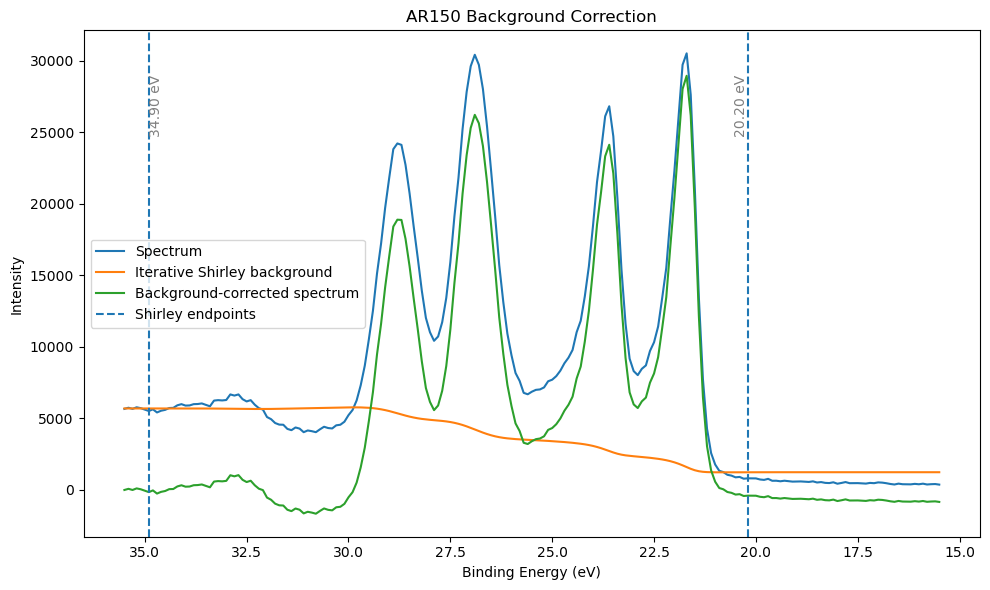

In [99]:
plt.figure(figsize=(10, 6))

plt.plot(
    x_original,
    y_for_analysis,
    label="Spectrum"
)

plt.plot(
    x_original,
    shirley,
    label="Iterative Shirley background"
)

plt.plot(
    x_original,
    corrected,
    label="Background-corrected spectrum"
)

plt.axvline(
    SHIRLEY_MIN_BE,
    linestyle="--",
    label="Shirley endpoints"
)

plt.axvline(
    SHIRLEY_MAX_BE,
    linestyle="--"
)

y_top = np.max(y_original)

plt.text(SHIRLEY_MIN_BE, y_top * 0.95, f"{SHIRLEY_MIN_BE:.2f} eV",
         rotation=90, va="top", ha="right", fontsize=10, color="gray")

plt.text(SHIRLEY_MAX_BE, y_top * 0.95, f"{SHIRLEY_MAX_BE:.2f} eV",
         rotation=90, va="top", ha="left", fontsize=10, color="gray")
plt.title(f"{base_name} Background Correction")
plt.xlabel("Binding Energy (eV)")
plt.ylabel("Intensity")
plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

# Advanced single-spectrum Ta 4f fitting pipeline

This notebook fits **one Ta 4f .xy spectrum at a time** and retains the sequence:

1. adaptive Shirley background subtraction,
2. fully coupled nonlinear simultaneous optimization,
3. post-fit binding-energy shift,
4. area, uncertainty, residual, and stability reporting.

The fitted components are:

- Ta metal 4f doublet,
- Ta2O5 4f doublet,
- Ta suboxide 4f doublet,
- O 2s singlet.

Physical constraints used in the model:

- Ta 4f doublet separation = **1.91 eV**;
- Ta 4f7/2 : 4f5/2 area ratio = **4 : 3**;
- Ta metal uses an asymmetric **LA(1.1, 7, 25)-style** line shape;
- Ta2O5 and Ta suboxide use a fixed **GL(30)-style** line shape and share one FWHM;
- O 2s uses a fixed **GL(30)-style** line shape with an independent broad FWHM;
- Ta metal 4f7/2 is shifted to **21.60 eV after fitting**;
- the previously measured average area fractions are used only as multistart initialization, never as fixed area ratios or correction factors.

All areas, centers, widths, the O 2s width, and the small residual-baseline terms are optimized in the same nonlinear least-squares problem. Species curves are allowed to overlap naturally.


In [100]:
# ============================================================
# PREPARE THE BACKGROUND-CORRECTED DATA
#
# The corrected data are not shifted upward. A bounded residual
# offset and slope are fitted simultaneously later. Those baseline
# terms are excluded from all reported species areas.
# ============================================================

x = np.asarray(x_original, dtype=float)
y = np.asarray(corrected, dtype=float)

mask = (
    (x >= SHIRLEY_MIN_BE)
    & (x <= SHIRLEY_MAX_BE)
    & np.isfinite(x)
    & np.isfinite(y)
)

x = x[mask]
y = y[mask]

order = np.argsort(x)
x = x[order]
y = y[order]

intensity_shift = 0.0
x_centered = x - np.mean(x)

print(f"Fitting window: {x.min():.3f} to {x.max():.3f} eV")
print("Artificial corrected-intensity shift: disabled")
print(f"Minimum corrected intensity: {np.min(y):.6f}")


Fitting window: 20.200 to 34.900 eV
Artificial corrected-intensity shift: disabled
Minimum corrected intensity: -1690.488151


In [101]:
# ============================================================
# PHYSICAL CONSTANTS AND LINE SHAPES — Ta 4f
# ============================================================

# Ta 4f spin-orbit physics
SPLIT = 1.91

# Ta 4f5/2 area relative to Ta 4f7/2:
# 4f7/2 : 4f5/2 = 4 : 3
RATIO = 3.0 / 4.0

# Fixed GL(30)-style Gaussian/Lorentzian mixing used for
# Ta2O5, Ta suboxide, and O 2s.
GL_ETA = 0.30

# LA(1.1, 7, 25)-style parameters for metallic Ta.
# This keeps the same asymmetric-line-shape logic used in the Nb notebook.
TA_METAL_LA_ALPHA = 1.1
TA_METAL_LA_BETA = 7.0
TA_METAL_LA_SMOOTHING_FRACTION = 0.25



# ------------------------------------------------------------
# Ta metal FWHM calibration
# ------------------------------------------------------------

REFERENCE_METAL_CALIBRATION = np.mean([
    0.52 / 0.685,
    0.54 / 0.691,
    0.54 / 0.720,
])

TA_METAL_FWHM_CALIBRATION = REFERENCE_METAL_CALIBRATION

def true_voigt_from_fwhm_eta(x_values, center, fwhm, eta):
    """
    Voigt profile parameterized by approximate total FWHM and a fixed
    Lorentzian fraction eta.

    For this Ta model eta is fixed at 0.30 for GL(30)-style components.
    """
    x_values = np.asarray(x_values, dtype=float)
    fwhm = max(float(fwhm), 1e-8)
    eta = float(np.clip(eta, 0.0, 1.0))

    lorentz_fwhm = max(eta * fwhm, 1e-8)

    inside = (
        (fwhm - 0.5346 * lorentz_fwhm) ** 2
        - 0.2166 * lorentz_fwhm ** 2
    )
    gaussian_fwhm = np.sqrt(max(inside, 1e-12))

    sigma = gaussian_fwhm / 2.354820045
    gamma = lorentz_fwhm / 2.0

    profile = voigt_profile(x_values - center, sigma, gamma)
    maximum = np.max(profile)

    if not np.isfinite(maximum) or maximum <= 0:
        return np.zeros_like(x_values)

    return profile / maximum


def gl30_peak(x_values, height, center, fwhm):
    """Fixed GL(30)-style symmetric peak used for oxides and O 2s."""
    return float(height) * true_voigt_from_fwhm_eta(
        x_values,
        center,
        fwhm,
        GL_ETA,
    )


def ta_doublet_gl30_height(x_values, height, center_7_2, fwhm):
    """
    Symmetric Ta 4f doublet with:
      separation = 1.91 eV
      4f7/2 : 4f5/2 area/intensity ratio = 4 : 3
    """
    p_7_2 = gl30_peak(
        x_values,
        height,
        center_7_2,
        fwhm,
    )

    p_5_2 = gl30_peak(
        x_values,
        height * RATIO,
        center_7_2 + SPLIT,
        fwhm,
    )

    return p_7_2 + p_5_2


def LA_peak(
    x_values,
    height,
    center,
    fwhm_parameter,
    alpha=TA_METAL_LA_ALPHA,
    beta=TA_METAL_LA_BETA,
    smoothing_fraction=TA_METAL_LA_SMOOTHING_FRACTION,
):
    """
    Asymmetric Lorentzian-like metallic Ta line shape.

    The optimized width parameter is expressed directly in eV.
    No empirical Ta FWHM calibration is applied in this notebook.

    The final metallic FWHM reported later is measured numerically from
    the actual fitted 4f7/2 profile so it can be compared with CasaXPS.
    """
    x_values = np.asarray(x_values, dtype=float)

    # Choose gamma so that the unsmoothed asymmetric profile has
    # approximately the requested total FWHM.
    alpha = max(float(alpha), 1e-8)
    beta = max(float(beta), 1e-8)
    target_fwhm = max(float(fwhm_parameter), 1e-8)

    left_factor = np.sqrt(max(2.0 ** (1.0 / beta) - 1.0, 1e-12))
    right_factor = np.sqrt(max(2.0 ** (1.0 / alpha) - 1.0, 1e-12))
    gamma = target_fwhm / max(left_factor + right_factor, 1e-12)

    lorentz = 1.0 / (1.0 + ((x_values - center) / gamma) ** 2)

    profile = np.zeros_like(x_values, dtype=float)
    low_be = x_values <= center
    profile[low_be] = lorentz[low_be] ** beta
    profile[~low_be] = lorentz[~low_be] ** alpha

    if len(x_values) > 1 and smoothing_fraction > 0:
        sorted_unique = np.sort(np.unique(x_values))
        if len(sorted_unique) > 1:
            step = float(np.median(np.diff(sorted_unique)))
            smoothing_sigma_ev = max(
                smoothing_fraction * target_fwhm,
                0.005,
            )
            sigma_points = smoothing_sigma_ev / max(abs(step), 1e-12)

            profile = gaussian_filter1d(
                profile,
                sigma=max(sigma_points, 1e-6),
                mode="nearest",
            )

    maximum = np.max(profile)
    if not np.isfinite(maximum) or maximum <= 0:
        return np.zeros_like(x_values)

    return float(height) * profile / maximum


def ta_metal_doublet_height(x_values, height, center_7_2, fwhm_parameter):
    p_7_2 = LA_peak(
        x_values,
        height,
        center_7_2,
        fwhm_parameter,
    )

    p_5_2 = LA_peak(
        x_values,
        height * RATIO,
        center_7_2 + SPLIT,
        fwhm_parameter,
    )

    return p_7_2 + p_5_2


def numerical_metal_fwhm(center_7_2, fwhm_parameter):
    """
    Measure the FWHM of the fitted Ta-metal 4f7/2 line numerically.
    This is intentionally uncalibrated against CasaXPS.
    """
    grid = np.linspace(center_7_2 - 2.0, center_7_2 + 2.0, 20001)
    profile = LA_peak(
        grid,
        1.0,
        center_7_2,
        fwhm_parameter,
    )

    if not np.any(np.isfinite(profile)):
        return np.nan

    peak = np.nanmax(profile)
    if not np.isfinite(peak) or peak <= 0:
        return np.nan

    half = 0.5 * peak
    above = np.flatnonzero(profile >= half)

    if len(above) < 2:
        return np.nan

    return float(grid[above[-1]] - grid[above[0]])


print("Ta 4f doublet separation = 1.91 eV")
print("Ta 4f7/2 : 4f5/2 area ratio = 4 : 3")
print("Ta2O5 / suboxide / O 2s line shape = fixed GL(30)-style")
print("Ta metal line shape = LA(1.1, 7, 25)-style")
print("Ta metal FWHM calibration = disabled")


Ta 4f doublet separation = 1.91 eV
Ta 4f7/2 : 4f5/2 area ratio = 4 : 3
Ta2O5 / suboxide / O 2s line shape = fixed GL(30)-style
Ta metal line shape = LA(1.1, 7, 25)-style
Ta metal FWHM calibration = disabled


In [102]:
# ============================================================
# AREA-NORMALIZED COMPONENTS
#
# Every fitted area is the numerical integral of that complete
# species contribution over the selected fitting window.
# For Ta species, "area" therefore means the combined 4f7/2 + 4f5/2 area.
# ============================================================

AREA_GRID = np.linspace(np.min(x), np.max(x), 12000)


def normalize_on_area_grid(unit_curve_on_area_grid):
    area = float(simpson(unit_curve_on_area_grid, x=AREA_GRID))

    if not np.isfinite(area) or abs(area) < 1e-15:
        raise ValueError("Component normalization area is zero or non-finite.")

    return abs(area)


def ta_metal_component(x_values, area, center_7_2, metal_fwhm_parameter):
    normalization_curve = ta_metal_doublet_height(
        AREA_GRID,
        1.0,
        center_7_2,
        metal_fwhm_parameter,
    )
    normalization = normalize_on_area_grid(normalization_curve)

    requested_curve = ta_metal_doublet_height(
        np.asarray(x_values, dtype=float),
        1.0,
        center_7_2,
        metal_fwhm_parameter,
    )

    return float(area) * requested_curve / normalization


def ta_oxide_component(
    x_values,
    area,
    center_7_2,
    shared_oxide_fwhm,
):
    normalization_curve = ta_doublet_gl30_height(
        AREA_GRID,
        1.0,
        center_7_2,
        shared_oxide_fwhm,
    )
    normalization = normalize_on_area_grid(normalization_curve)

    requested_curve = ta_doublet_gl30_height(
        np.asarray(x_values, dtype=float),
        1.0,
        center_7_2,
        shared_oxide_fwhm,
    )

    return float(area) * requested_curve / normalization


def o2s_component(
    x_values,
    area,
    center,
    fwhm,
):
    normalization_curve = gl30_peak(
        AREA_GRID,
        1.0,
        center,
        fwhm,
    )
    normalization = normalize_on_area_grid(normalization_curve)

    requested_curve = gl30_peak(
        np.asarray(x_values, dtype=float),
        1.0,
        center,
        fwhm,
    )

    return float(area) * requested_curve / normalization


In [103]:
# ============================================================
# FULLY COUPLED SIMULTANEOUS Ta MODEL
#
# Parameters:
#  0  Ta metal total 4f area
#  1  Ta metal 4f7/2 position
#  2  Ta metal FWHM parameter (uncalibrated, eV)
#  3  shared Ta2O5 / suboxide FWHM
#  4  Ta2O5 total 4f area
#  5  Ta2O5 4f7/2 position
#  6  Ta suboxide total 4f area
#  7  Ta suboxide 4f7/2 position
#  8  O 2s area
#  9  O 2s position
# 10  O 2s FWHM
# 11  residual baseline offset
# 12  residual baseline slope
#
# All parameters are optimized simultaneously.
# Baseline terms are excluded from every reported species area.
# ============================================================

def component_curves(x_values, p):
    ta_metal = ta_metal_component(
        x_values,
        area=p[0],
        center_7_2=p[1],
        metal_fwhm_parameter=p[2],
    )

    ta2o5 = ta_oxide_component(
        x_values,
        area=p[4],
        center_7_2=p[5],
        shared_oxide_fwhm=p[3],
    )

    suboxide = ta_oxide_component(
        x_values,
        area=p[6],
        center_7_2=p[7],
        shared_oxide_fwhm=p[3],
    )

    o2s = o2s_component(
        x_values,
        area=p[8],
        center=p[9],
        fwhm=p[10],
    )

    return ta_metal, ta2o5, suboxide, o2s


def residual_baseline(x_values, p):
    x_values = np.asarray(x_values, dtype=float)
    return p[11] + p[12] * (x_values - np.mean(x))


def total_model(x_values, p):
    components = np.sum(component_curves(x_values, p), axis=0)
    return components + residual_baseline(x_values, p)


In [104]:
# ============================================================
# STARTING VALUES, SOFT PRIORS, AND PARAMETER BOUNDS
# ============================================================

# ------------------------------------------------------------
# 1. Estimate total background-corrected spectrum area
# ------------------------------------------------------------

def pchip_integral(x_values, y_values):
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    valid = np.isfinite(x_values) & np.isfinite(y_values)
    x_values = x_values[valid]
    y_values = y_values[valid]

    order = np.argsort(x_values)
    x_values = x_values[order]
    y_values = y_values[order]

    x_values, unique_indices = np.unique(
        x_values,
        return_index=True,
    )
    y_values = y_values[unique_indices]

    spline = PchipInterpolator(
        x_values,
        y_values,
        extrapolate=False,
    )

    antiderivative = spline.antiderivative()

    return float(
        abs(
            antiderivative(x_values[-1])
            - antiderivative(x_values[0])
        )
    )


total_area_guess = max(
    pchip_integral(x, y),
    1.0,
)


# ------------------------------------------------------------
# 2. Physical position priors
#
# Ta metal = post-fit calibration reference only.
# The other priors are applied AFTER the common energy shift.
# ------------------------------------------------------------

REFERENCE_METAL_BE = 21.60

CENTER_PRIORS = {
    "ta2o5": {
        "center": 26.70,
        "sigma": 0.30,
    },
    "suboxide": {
        "center": 23.40,
        "sigma": 0.30,
    },
    "o2s": {
        "center": 24.00,
        "sigma": 1.00,
    },
}

# Weak width priors improve multistart stability while retaining the
# requested hard bounds.
SHAPE_PRIORS = {
    "metal_fwhm": {
        "center": 0.55,
        "sigma": 0.12,
    },
    "oxide_fwhm": {
        "center": 1.08,
        "sigma": 0.10,
    },
    "o2s_fwhm": {
        "center": 3.50,
        "sigma": 0.75,
    },
}

USE_SHAPE_PRIORS = True
PRIOR_STRENGTH = 1.0

metal_fwhm_guess = SHAPE_PRIORS["metal_fwhm"]["center"]
shared_oxide_fwhm_guess = SHAPE_PRIORS["oxide_fwhm"]["center"]
o2s_fwhm_guess = SHAPE_PRIORS["o2s_fwhm"]["center"]


# ------------------------------------------------------------
# 3. Area starting guesses
#
# Measured average percentages from the three reference Ta spectra.
# They are INITIALIZATION ONLY. Final fitted areas are free.
# ------------------------------------------------------------

initial_fractions = np.array([
    0.4743,  # Ta metal
    0.4719,  # Ta2O5
    0.0321,  # Ta suboxide
    0.0216,  # O 2s
], dtype=float)

initial_fractions /= initial_fractions.sum()
initial_areas = total_area_guess * initial_fractions


# ------------------------------------------------------------
# 4. Position bounds
#
# A common pre-shift instrumental offset is allowed.
# Ta2O5 / suboxide / O 2s are additionally constrained by
# physically motivated post-shift priors in the objective.
# ------------------------------------------------------------

COMMON_SHIFT_LIMIT = 2.0

metal_bounds = (
    REFERENCE_METAL_BE - COMMON_SHIFT_LIMIT,
    REFERENCE_METAL_BE + COMMON_SHIFT_LIMIT,
)

ta2o5_bounds = (
    CENTER_PRIORS["ta2o5"]["center"] - COMMON_SHIFT_LIMIT - 0.60,
    CENTER_PRIORS["ta2o5"]["center"] + COMMON_SHIFT_LIMIT + 0.60,
)

suboxide_bounds = (
    CENTER_PRIORS["suboxide"]["center"] - COMMON_SHIFT_LIMIT - 0.60,
    CENTER_PRIORS["suboxide"]["center"] + COMMON_SHIFT_LIMIT + 0.60,
)

o2s_bounds = (
    CENTER_PRIORS["o2s"]["center"] - COMMON_SHIFT_LIMIT - 2.00,
    CENTER_PRIORS["o2s"]["center"] + COMMON_SHIFT_LIMIT + 2.00,
)


# ------------------------------------------------------------
# 5. Residual-baseline bounds
# ------------------------------------------------------------

edge_count = max(
    6,
    int(round(0.12 * len(y))),
)

edge_values = np.concatenate([
    y[:edge_count],
    y[-edge_count:],
])

edge_mad = (
    1.4826
    * np.median(
        np.abs(
            edge_values
            - np.median(edge_values)
        )
    )
)

edge_scale = max(
    1e-6,
    edge_mad,
    0.01 * max(float(np.ptp(y)), 1.0),
)

baseline_offset_limit = 3.0 * edge_scale

baseline_slope_limit = (
    baseline_offset_limit
    / max(float(np.ptp(x)), 1e-6)
)


# ------------------------------------------------------------
# 6. Initial parameter vector
# ------------------------------------------------------------

p0 = np.array([
    initial_areas[0],     # Ta metal area
    REFERENCE_METAL_BE,   # Ta metal pre-shift center guess
    metal_fwhm_guess,     # Ta metal FWHM parameter

    shared_oxide_fwhm_guess,

    initial_areas[1],     # Ta2O5 area
    CENTER_PRIORS["ta2o5"]["center"],

    initial_areas[2],     # suboxide area
    CENTER_PRIORS["suboxide"]["center"],

    initial_areas[3],     # O 2s area
    CENTER_PRIORS["o2s"]["center"],
    o2s_fwhm_guess,

    0.0,                  # residual baseline offset
    0.0,                  # residual baseline slope
], dtype=float)


# ------------------------------------------------------------
# 7. Hard parameter bounds
# ------------------------------------------------------------

maximum_component_area = 2.0 * total_area_guess

lower = np.array([
    0.0,
    metal_bounds[0],
    0.25,                 # Ta metal FWHM parameter lower bound

    0.60,                 # shared Ta oxide FWHM

    0.0,
    ta2o5_bounds[0],

    0.0,
    suboxide_bounds[0],

    0.0,
    o2s_bounds[0],
    2.50,                 # O 2s FWHM lower bound

    -baseline_offset_limit,
    -baseline_slope_limit,
], dtype=float)


upper = np.array([
    maximum_component_area,
    metal_bounds[1],
    0.70,                 # Ta metal FWHM parameter < 0.7 eV

    1.20,                 # Ta2O5/suboxide FWHM < 1.2 eV

    maximum_component_area,
    ta2o5_bounds[1],

    maximum_component_area,
    suboxide_bounds[1],

    maximum_component_area,
    o2s_bounds[1],
    5.00,                 # O 2s FWHM upper bound

    baseline_offset_limit,
    baseline_slope_limit,
], dtype=float)


# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------

labels = [
    "Ta metal",
    "Ta2O5",
    "TaOx",
    "O 2s",
]

print("\nINITIAL Ta FIT SETUP\n")
print(f"Estimated total area: {total_area_guess:.2f}")

for label, fraction, area in zip(
    labels,
    initial_fractions,
    initial_areas,
):
    print(
        f"{label:<8} start = "
        f"{100.0 * fraction:6.2f}% "
        f"(area {area:.2f})"
    )

print("\nHard width constraints:")
print("Ta metal width parameter: 0.25–0.70 eV")
print("Ta2O5 / TaOx shared FWHM: 0.60–1.20 eV")
print("O 2s FWHM: 2.50–5.00 eV")



INITIAL Ta FIT SETUP

Estimated total area: 102734.58
Ta metal start =  47.43% (area 48731.89)
Ta2O5    start =  47.19% (area 48485.30)
TaOx     start =   3.21% (area 3298.11)
O 2s     start =   2.16% (area 2219.29)

Hard width constraints:
Ta metal width parameter: 0.25–0.70 eV
Ta2O5 / TaOx shared FWHM: 0.60–1.20 eV
O 2s FWHM: 2.50–5.00 eV


### Multistart simultaneous Ta fit — this may take 1–2 minutes


In [105]:
# ============================================================
# MULTI-START, FULLY COUPLED SIMULTANEOUS Ta FIT
# ============================================================

edge_count = max(6, int(round(0.12 * len(y))))
edge_values = np.concatenate([y[:edge_count], y[-edge_count:]])
edge_differences = np.diff(edge_values)

if len(edge_differences) > 0:
    diff_median = np.median(edge_differences)
    noise_sigma = (
        1.4826
        * np.median(np.abs(edge_differences - diff_median))
        / np.sqrt(2.0)
    )
else:
    noise_sigma = np.nan

fallback_noise = max(
    1e-6,
    0.01 * max(float(np.ptp(y)), 1.0),
)

if not np.isfinite(noise_sigma) or noise_sigma <= 0:
    noise_sigma = fallback_noise

sigma = np.full_like(y, noise_sigma, dtype=float)

AREA_INDICES = (0, 4, 6, 8)
CENTER_INDICES = (1, 5, 7, 9)

# Mild region balancing helps the small suboxide and broad O 2s
# remain visible to the objective without preventing peak overlap.
USE_REGION_BALANCING = True
REGION_WEIGHT_CAP = (0.75, 1.75)


def make_region_weights(x_values):
    if not USE_REGION_BALANCING:
        return np.ones_like(x_values, dtype=float)

    x_values = np.asarray(x_values, dtype=float)

    # Broad chemically informative regions in the Ta 4f / O 2s window.
    boundaries = np.array([
        22.5,
        24.5,
        26.0,
        27.8,
        29.5,
    ])

    region_id = np.digitize(x_values, boundaries)
    weights = np.ones_like(x_values, dtype=float)

    unique_regions = np.unique(region_id)
    target_count = len(x_values) / max(len(unique_regions), 1)

    for rid in unique_regions:
        region_mask = region_id == rid
        count = max(np.count_nonzero(region_mask), 1)
        weight = np.sqrt(target_count / count)
        weights[region_mask] = weight

    weights = np.clip(
        weights,
        REGION_WEIGHT_CAP[0],
        REGION_WEIGHT_CAP[1],
    )

    weights /= np.sqrt(np.mean(weights ** 2))
    return weights


region_weights = make_region_weights(x)


def shifted_positions_from_parameters(p):
    shift = REFERENCE_METAL_BE - p[1]

    return np.array([
        p[1] + shift,  # Ta metal
        p[5] + shift,  # Ta2O5
        p[7] + shift,  # TaOx
        p[9] + shift,  # O 2s
    ], dtype=float)


def position_prior_residuals(p):
    shifted = shifted_positions_from_parameters(p)

    # Ta metal is the post-fit calibration reference and therefore
    # does not add an independent position prior residual.
    return np.array([
        (
            shifted[1] - CENTER_PRIORS["ta2o5"]["center"]
        ) / CENTER_PRIORS["ta2o5"]["sigma"],

        (
            shifted[2] - CENTER_PRIORS["suboxide"]["center"]
        ) / CENTER_PRIORS["suboxide"]["sigma"],

        (
            shifted[3] - CENTER_PRIORS["o2s"]["center"]
        ) / CENTER_PRIORS["o2s"]["sigma"],
    ], dtype=float)


def shape_prior_residuals(p):
    if not USE_SHAPE_PRIORS:
        return np.empty(0, dtype=float)

    return np.array([
        (
            p[2] - SHAPE_PRIORS["metal_fwhm"]["center"]
        ) / SHAPE_PRIORS["metal_fwhm"]["sigma"],

        (
            p[3] - SHAPE_PRIORS["oxide_fwhm"]["center"]
        ) / SHAPE_PRIORS["oxide_fwhm"]["sigma"],

        (
            p[10] - SHAPE_PRIORS["o2s_fwhm"]["center"]
        ) / SHAPE_PRIORS["o2s_fwhm"]["sigma"],
    ], dtype=float)


def baseline_prior_residuals(p):
    return np.array([
        p[11] / max(baseline_offset_limit / 2.0, 1e-12),
        p[12] / max(baseline_slope_limit / 2.0, 1e-12),
    ], dtype=float)


def data_residual_vector(p):
    raw = (total_model(x, p) - y) / sigma
    return region_weights * raw


def residual_vector(p):
    return np.concatenate([
        data_residual_vector(p),
        PRIOR_STRENGTH * position_prior_residuals(p),
        PRIOR_STRENGTH * shape_prior_residuals(p),
        0.50 * baseline_prior_residuals(p),
    ])


# ------------------------------------------------------------
# Physically motivated multistart initialization
# ------------------------------------------------------------

rng = np.random.default_rng(42)
starts = [p0.copy()]

# Center the Dirichlet distribution on the measured average fractions.
# Concentration controls start-to-start variation only; it does NOT
# constrain final fitted areas.
DIRICHLET_CONCENTRATION = 35.0
dirichlet_alpha = np.maximum(
    initial_fractions * DIRICHLET_CONCENTRATION,
    0.25,
)

NUMBER_RANDOM_STARTS = 29

for _ in range(NUMBER_RANDOM_STARTS):
    trial = p0.copy()

    random_fractions = rng.dirichlet(dirichlet_alpha)
    random_total_area = total_area_guess * rng.lognormal(
        mean=0.0,
        sigma=0.12,
    )
    random_areas = random_total_area * random_fractions

    for idx, area in zip(AREA_INDICES, random_areas):
        trial[idx] = area

    # Draw one common instrumental offset, then perturb chemical
    # separations around the post-shift physical priors.
    common_offset = np.clip(
        rng.normal(0.0, 0.40),
        -COMMON_SHIFT_LIMIT,
        COMMON_SHIFT_LIMIT,
    )

    trial[1] = REFERENCE_METAL_BE + common_offset

    trial[5] = (
        CENTER_PRIORS["ta2o5"]["center"]
        + common_offset
        + rng.normal(
            0.0,
            0.50 * CENTER_PRIORS["ta2o5"]["sigma"],
        )
    )

    trial[7] = (
        CENTER_PRIORS["suboxide"]["center"]
        + common_offset
        + rng.normal(
            0.0,
            0.50 * CENTER_PRIORS["suboxide"]["sigma"],
        )
    )

    trial[9] = (
        CENTER_PRIORS["o2s"]["center"]
        + common_offset
        + rng.normal(
            0.0,
            0.40 * CENTER_PRIORS["o2s"]["sigma"],
        )
    )

    trial[2] = np.clip(
        rng.normal(metal_fwhm_guess, 0.08),
        lower[2],
        upper[2],
    )

    trial[3] = np.clip(
        rng.normal(shared_oxide_fwhm_guess, 0.08),
        lower[3],
        upper[3],
    )

    trial[10] = np.clip(
        rng.normal(o2s_fwhm_guess, 0.45),
        lower[10],
        upper[10],
    )

    trial[11] = rng.normal(
        0.0,
        baseline_offset_limit / 3.0,
    )

    trial[12] = rng.normal(
        0.0,
        baseline_slope_limit / 3.0,
    )

    trial = np.clip(
        trial,
        lower + 1e-10,
        upper - 1e-10,
    )

    starts.append(trial)


# ------------------------------------------------------------
# Stage 1: coarse screening
# ------------------------------------------------------------

coarse_candidates = []

print(f"Beginning coarse fitting of {len(starts)} starts...")

for start_number, start in enumerate(starts):
    try:
        result = least_squares(
            residual_vector,
            start,
            bounds=(lower, upper),
            method="trf",
            x_scale="jac",
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=3000,
            ftol=1e-7,
            xtol=1e-7,
            gtol=1e-7,
        )

        if np.all(np.isfinite(result.x)):
            full_score = float(
                np.mean(residual_vector(result.x) ** 2)
            )
            data_score = float(
                np.mean(data_residual_vector(result.x) ** 2)
            )

            coarse_candidates.append(
                (full_score, data_score, start_number, result)
            )

    except (ValueError, RuntimeError, FloatingPointError):
        continue

    if (start_number + 1) % 5 == 0:
        print(
            f"Completed {start_number + 1} "
            f"of {len(starts)} starts"
        )


if not coarse_candidates:
    raise RuntimeError(
        "All coarse simultaneous Ta fitting starts failed."
    )

coarse_candidates.sort(
    key=lambda item: item[0]
)


# ------------------------------------------------------------
# Stage 2: refine best solutions
# ------------------------------------------------------------

NUMBER_TO_REFINE = min(
    5,
    len(coarse_candidates),
)

refined_candidates = []

print(
    f"\nRefining the best "
    f"{NUMBER_TO_REFINE} solutions..."
)

for rank, coarse_candidate in enumerate(
    coarse_candidates[:NUMBER_TO_REFINE],
    start=1,
):
    _, _, original_start_number, coarse_result = coarse_candidate

    try:
        refined_result = least_squares(
            residual_vector,
            coarse_result.x,
            bounds=(lower, upper),
            method="trf",
            x_scale="jac",
            loss="soft_l1",
            f_scale=1.0,
            max_nfev=15000,
            ftol=1e-9,
            xtol=1e-9,
            gtol=1e-9,
        )

        if np.all(np.isfinite(refined_result.x)):
            refined_full_score = float(
                np.mean(
                    residual_vector(
                        refined_result.x
                    ) ** 2
                )
            )

            refined_data_score = float(
                np.mean(
                    data_residual_vector(
                        refined_result.x
                    ) ** 2
                )
            )

            refined_candidates.append(
                (
                    refined_full_score,
                    refined_data_score,
                    original_start_number,
                    refined_result,
                )
            )

            print(
                f"Refinement {rank}: "
                f"full score = "
                f"{refined_full_score:.8g}"
            )

    except (ValueError, RuntimeError, FloatingPointError):
        continue


candidates = (
    refined_candidates
    if refined_candidates
    else coarse_candidates
)

candidates.sort(
    key=lambda item: item[0]
)

(
    best_score,
    best_data_score,
    best_start_number,
    best_result,
) = candidates[0]

popt = best_result.x

print("\nFINAL Ta MULTI-START RESULTS\n")
print(f"Estimated point-noise sigma: {noise_sigma:.6g}")
print(f"Region balancing enabled: {USE_REGION_BALANCING}")
print(f"Successful coarse starts: {len(coarse_candidates)} / {len(starts)}")
print(f"Successful refined fits: {len(refined_candidates)} / {NUMBER_TO_REFINE}")
print(f"Best original starting trial: {best_start_number}")
print(f"Best full penalized score: {best_score:.8g}")
print(f"Best data-only reduced score: {best_data_score:.8g}")
print(f"Residual baseline offset: {popt[11]:+.6g}")
print(f"Residual baseline slope: {popt[12]:+.6g} intensity/eV")

print("\nBest available solutions:")
for rank, (
    full_score,
    data_score,
    start_number,
    result,
) in enumerate(
    candidates[:5],
    start=1,
):
    print(
        f"{rank}: "
        f"full = {full_score:.8g}, "
        f"data = {data_score:.8g}, "
        f"start = {start_number}, "
        f"nfev = {result.nfev}"
    )


Beginning coarse fitting of 30 starts...
Completed 5 of 30 starts
Completed 10 of 30 starts
Completed 15 of 30 starts
Completed 20 of 30 starts
Completed 25 of 30 starts
Completed 30 of 30 starts

Refining the best 5 solutions...
Refinement 1: full score = 14.49274
Refinement 2: full score = 14.492776
Refinement 3: full score = 14.492775
Refinement 4: full score = 14.492775
Refinement 5: full score = 14.492775

FINAL Ta MULTI-START RESULTS

Estimated point-noise sigma: 125.484
Region balancing enabled: True
Successful coarse starts: 30 / 30
Successful refined fits: 5 / 5
Best original starting trial: 19
Best full penalized score: 14.49274
Best data-only reduced score: 15.22543
Residual baseline offset: -1243.65
Residual baseline slope: +113.942 intensity/eV

Best available solutions:
1: full = 14.49274, data = 15.22543, start = 19, nfev = 7
2: full = 14.492775, data = 15.225463, start = 11, nfev = 6
3: full = 14.492775, data = 15.225464, start = 8, nfev = 6
4: full = 14.492775, data = 

In [106]:
# ============================================================
# EXTRACT UNSHIFTED Ta FIT PARAMETERS
# ============================================================

component_names = [
    "Ta metal",
    "Ta2O5",
    "TaOx",
    "O 2s",
]

area_indices = (0, 4, 6, 8)
center_indices = (1, 5, 7, 9)

fitted_areas = popt[list(area_indices)]
unshifted_centers = popt[list(center_indices)]

# Raw numerical FWHM of the asymmetric metal peak
metal_fwhm_raw = numerical_metal_fwhm(
    popt[1],
    popt[2],
)

# Convert to CasaXPS-equivalent reported FWHM
metal_fwhm_reported = (
    metal_fwhm_raw
    * TA_METAL_FWHM_CALIBRATION
)

shared_oxide_fwhm = popt[3]
o2s_fwhm = popt[10]

baseline_offset = popt[11]
baseline_slope = popt[12]

total_fitted_area = fitted_areas.sum()

reported_fwhms = np.array([
    metal_fwhm_reported,
    shared_oxide_fwhm,
    shared_oxide_fwhm,
    o2s_fwhm,
], dtype=float)

print(f"\nTotal fitted species area = {total_fitted_area:.2f}")
print(f"Residual baseline offset = {baseline_offset:+.6g}")
print(f"Residual baseline slope = {baseline_slope:+.6g} intensity/eV")
print(f"Fixed GL mixing = 70% Gaussian / 30% Lorentzian")
print("Ta 4f doublet separation = 1.91 eV")
print("Ta 4f7/2 : 4f5/2 area ratio = 4 : 3")
print("Ta metal FWHM calibration = disabled")



Total fitted species area = 121697.62
Residual baseline offset = -1243.65
Residual baseline slope = +113.942 intensity/eV
Fixed GL mixing = 70% Gaussian / 30% Lorentzian
Ta 4f doublet separation = 1.91 eV
Ta 4f7/2 : 4f5/2 area ratio = 4 : 3
Ta metal FWHM calibration = disabled


# Binding-energy shift

The simultaneous fit is completed first. Then the fitted Ta-metal 4f7/2 position
is used as the energy-calibration reference:

```python
shift = 21.600 - fitted_ta_metal_4f7_2
```

The same constant shift is applied to Ta2O5, TaOx, O 2s, and the plotted energy axis.


In [107]:
# ============================================================
# APPLY THE POST-FIT ENERGY SHIFT
# ============================================================

energy_shift = REFERENCE_METAL_BE - popt[1]

shifted_centers = unshifted_centers + energy_shift
x_shifted = x + energy_shift

shift_table = pd.DataFrame({
    "Species": component_names,
    "Unshifted position (eV)": np.round(
        unshifted_centers,
        3,
    ),
    "Shifted position (eV)": np.round(
        shifted_centers,
        3,
    ),
    "FWHM (eV)": np.round(
        reported_fwhms,
        3,
    ),
})

print(f"\n{base_name} Ta FIT RESULTS\n")
display(shift_table)
print(f"\nApplied energy shift = {energy_shift:+.3f} eV")



AR150 Ta FIT RESULTS



,Species,Unshifted position (eV),Shifted position (eV),FWHM (eV)
0,Ta metal,21.620,21.600,0.723
1,Ta2O5,26.879,26.859,1.051
2,TaOx,23.137,23.117,1.051
3,O 2s,23.221,23.201,5.000



Applied energy shift = -0.020 eV


In [108]:
# ============================================================
# RAW AREA VERIFICATION USING SIMPSON
# ============================================================

dense_components = component_curves(
    AREA_GRID,
    popt,
)

dense_species_total = np.sum(
    dense_components,
    axis=0,
)

dense_baseline = residual_baseline(
    AREA_GRID,
    popt,
)

raw_areas = np.array([
    abs(
        simpson(
            curve,
            x=AREA_GRID,
        )
    )
    for curve in dense_components
])

area_percentages = (
    100.0
    * fitted_areas
    / fitted_areas.sum()
)

area_table = pd.DataFrame({
    "Component": component_names,
    "Fitted area": fitted_areas,
    "Raw integrated area (Simpson)": raw_areas,
    "Difference": raw_areas - fitted_areas,
    "% of fitted total": area_percentages,
})

display(area_table)

corrected_data_signed_area = float(
    simpson(
        y,
        x=x,
    )
)

baseline_signed_area = float(
    simpson(
        dense_baseline,
        x=AREA_GRID,
    )
)

print("\nFixed symmetric GL(30)-style line shape")
print("----------------------------------------")
print("Applied to: Ta2O5, TaOx, and O 2s")
print("Gaussian contribution   : 70.0%")
print("Lorentzian contribution : 30.0%")

print(f"\nSigned corrected-data area = {corrected_data_signed_area:.2f}")
print(f"Sum of raw species areas   = {raw_areas.sum():.3f}")
print(f"Residual baseline area     = {baseline_signed_area:.3f}")
print(
    "Species + residual baseline = "
    f"{raw_areas.sum() + baseline_signed_area:.2f}"
)


,Component,Fitted area,Raw integrated area (Simpson),Difference,% of fitted total
0,Ta metal,45318.946008,45318.946008,7.275958e-12,37.238975
1,Ta2O5,55879.959597,55879.959597,7.275958e-12,45.917053
2,TaOx,1084.461929,1084.461929,0.000000e+00,0.891112
3,O 2s,19414.250862,19414.250862,-3.637979e-12,15.952860



Fixed symmetric GL(30)-style line shape
----------------------------------------
Applied to: Ta2O5, TaOx, and O 2s
Gaussian contribution   : 70.0%
Lorentzian contribution : 30.0%

Signed corrected-data area = 102724.60
Sum of raw species areas   = 121697.618
Residual baseline area     = -18281.585
Species + residual baseline = 103416.03


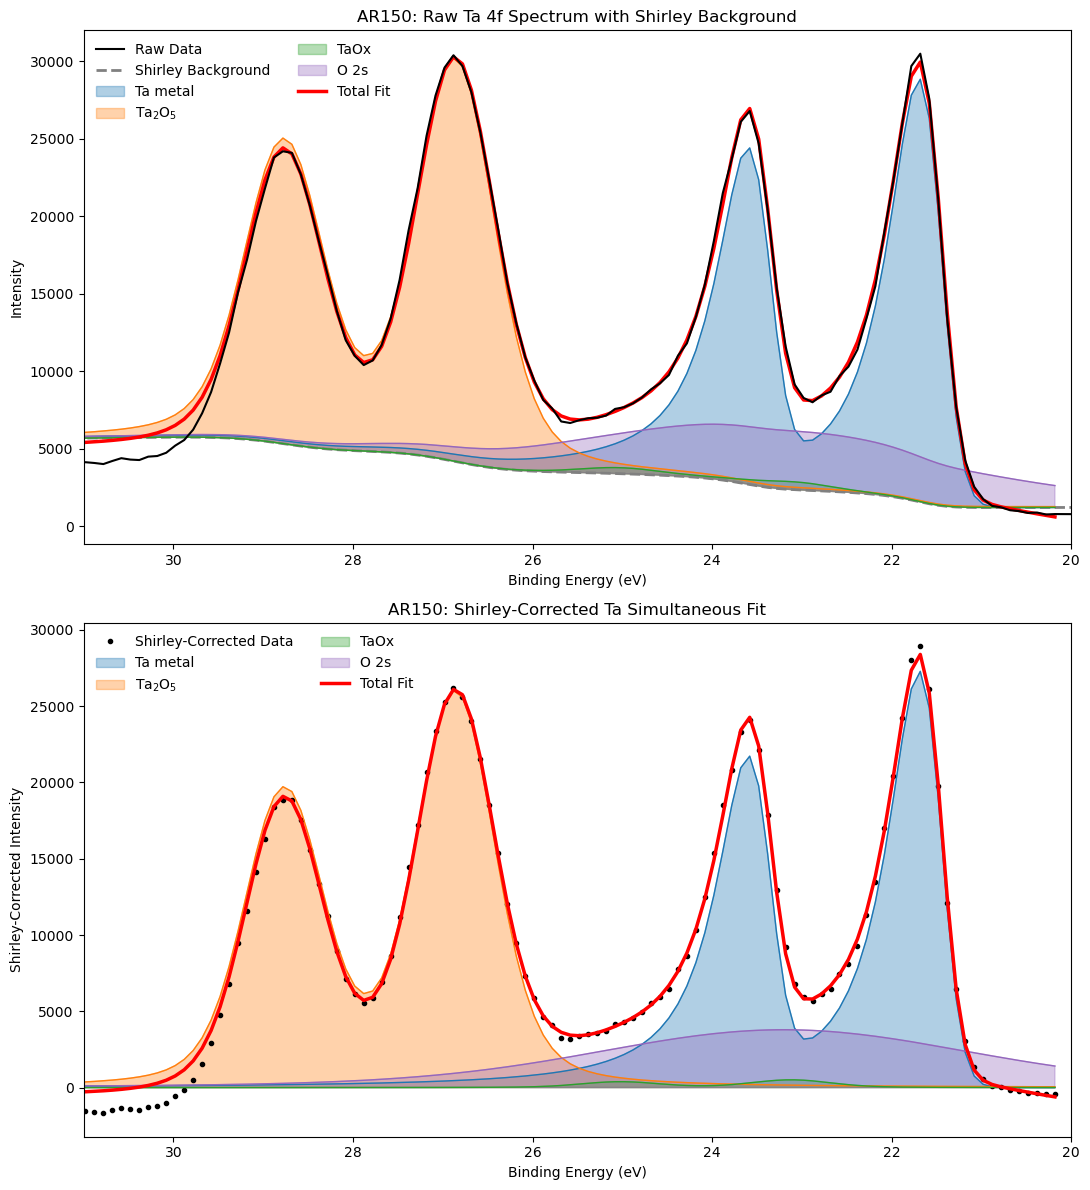

In [109]:
# ============================================================
# FINAL Ta FIT SUMMARY PLOTS
# ============================================================

model_at_x = total_model(x, popt)
ta_metal, ta2o5, taox, o2s = component_curves(x, popt)

# Shirley background on the fitting grid
valid_bg = np.isfinite(shirley)
bg_order = np.argsort(
    x_original[valid_bg]
)

shirley_at_x = np.interp(
    x,
    x_original[valid_bg][bg_order],
    shirley[valid_bg][bg_order],
)

raw_x_shifted = x_original + energy_shift

component_curves_at_x = [
    ta_metal,
    ta2o5,
    taox,
    o2s,
]

component_bg = [
    curve + shirley_at_x
    for curve in component_curves_at_x
]

total_fit_bg = (
    model_at_x
    + shirley_at_x
)

colors = {
    "metal": "#1f77b4",
    "ta2o5": "#ff7f0e",
    "taox": "#2ca02c",
    "o2s": "#9467bd",
}

plot_colors = [
    colors["metal"],
    colors["ta2o5"],
    colors["taox"],
    colors["o2s"],
]

plot_labels = [
    "Ta metal",
    r"Ta$_2$O$_5$",
    "TaOx",
    "O 2s",
]

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 12),
    sharex=True,
)

# ------------------------------------------------------------
# TOP: raw data + Shirley + full species fit
# ------------------------------------------------------------

ax1.plot(
    raw_x_shifted,
    y_original,
    color="black",
    lw=1.5,
    label="Raw Data",
    zorder=10,
)

ax1.plot(
    raw_x_shifted,
    shirley,
    "--",
    color="gray",
    lw=2,
    label="Shirley Background",
)

for curve_bg, color, label in zip(
    component_bg,
    plot_colors,
    plot_labels,
):
    ax1.fill_between(
        x_shifted,
        shirley_at_x,
        curve_bg,
        color=color,
        alpha=0.35,
        label=label,
    )

    ax1.plot(
        x_shifted,
        curve_bg,
        color=color,
        lw=1,
    )

ax1.plot(
    x_shifted,
    total_fit_bg,
    color="red",
    lw=2.5,
    label="Total Fit",
)

ax1.set_title(
    f"{base_name}: Raw Ta 4f Spectrum with Shirley Background"
)

ax1.set_ylabel("Intensity")
ax1.set_xlabel("Binding Energy (eV)")
ax1.tick_params(axis="x", labelbottom=True)
ax1.legend(frameon=False, ncol=2)


# ------------------------------------------------------------
# BOTTOM: Shirley-corrected simultaneous fit
# ------------------------------------------------------------

ax2.plot(
    x_shifted,
    y,
    "ko",
    markersize=3,
    label="Shirley-Corrected Data",
)

for curve, color, label in zip(
    component_curves_at_x,
    plot_colors,
    plot_labels,
):
    ax2.fill_between(
        x_shifted,
        0,
        curve,
        color=color,
        alpha=0.35,
        label=label,
    )

    ax2.plot(
        x_shifted,
        curve,
        color=color,
        lw=1,
    )

ax2.plot(
    x_shifted,
    model_at_x,
    color="red",
    lw=2.5,
    label="Total Fit",
)

ax2.set_title(
    f"{base_name}: Shirley-Corrected Ta Simultaneous Fit"
)

ax2.set_xlabel("Binding Energy (eV)")
ax2.set_ylabel("Shirley-Corrected Intensity")
ax2.legend(frameon=False, ncol=2)

# Conventional XPS direction.
# This range includes Ta metal through the Ta2O5 4f5/2 peak.
ax1.set_xlim(31, 20)

plt.tight_layout()
plt.show()


# FINAL TABLE AND RESIDUAL GRAPH

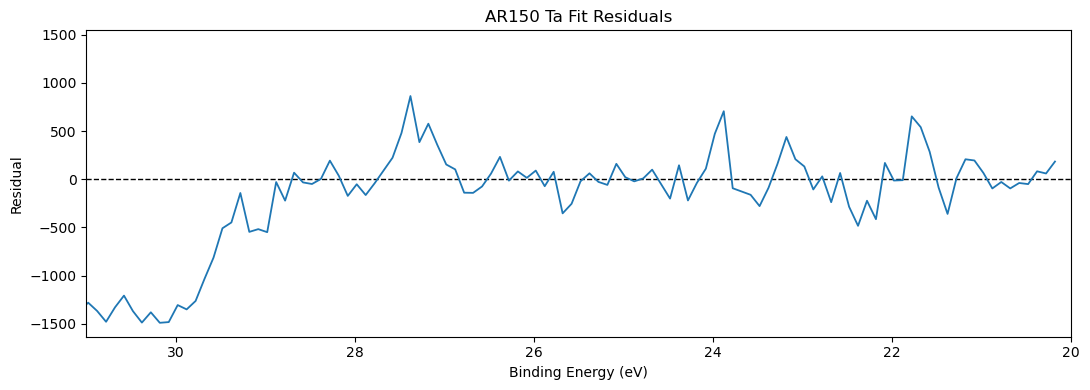

,Component,Area,Area 1-sigma,Shifted position (eV),Position 1-sigma (eV),FWHM (eV),FWHM 1-sigma (eV)
0,Ta metal,45318.946008,996.520690,21.600000,0.002931,0.723000,0.011504
1,Ta2O5,55879.959597,878.264460,26.858867,0.004920,1.051389,0.010191
2,TaOx,1084.461929,784.582051,23.117071,0.202772,1.051389,0.010191
3,O 2s,19414.250862,4455.889847,23.201245,0.169006,5.000000,0.584177


Residual standard deviation = 623.602339

Ta line-shape summary
---------------------
Ta metal: LA(1.1, 7, 25)-style, uncalibrated numerical FWHM
Ta2O5 / TaOx / O 2s: fixed GL(30)-style


In [110]:
# ============================================================
# RESIDUALS AND APPROXIMATE UNCERTAINTIES
# ============================================================

residuals = y - total_model(x, popt)

# ------------------------------------------------------------
# Residual plot
# ------------------------------------------------------------

plt.figure(figsize=(11, 4))

plt.axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1,
)

plt.plot(
    x_shifted,
    residuals,
    linewidth=1.3,
)

plt.xlabel("Binding Energy (eV)")
plt.ylabel("Residual")
plt.title(f"{base_name} Ta Fit Residuals")
plt.xlim(31, 20)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Approximate covariance and parameter uncertainties
# ------------------------------------------------------------

jacobian = best_result.jac
degrees_of_freedom = max(
    len(y) - len(popt),
    1,
)

try:
    covariance = np.linalg.pinv(
        jacobian.T @ jacobian
    )

    covariance *= (
        2.0
        * best_result.cost
        / degrees_of_freedom
    )

    parameter_std = np.sqrt(
        np.clip(
            np.diag(covariance),
            0.0,
            None,
        )
    )

except np.linalg.LinAlgError:
    covariance = np.full(
        (len(popt), len(popt)),
        np.nan,
    )

    parameter_std = np.full_like(
        popt,
        np.nan,
        dtype=float,
    )


# ------------------------------------------------------------
# Extract parameter uncertainties
# ------------------------------------------------------------

area_indices_array = np.asarray(
    area_indices,
    dtype=int,
)

center_indices_array = np.asarray(
    center_indices,
    dtype=int,
)

area_std = parameter_std[
    area_indices_array
]

position_std = parameter_std[
    center_indices_array
]

# The fitted metallic width parameter is not Casa-calibrated.
# Use its covariance uncertainty as an approximate uncertainty for
# the numerically reported metal FWHM until a Ta calibration is derived.
metal_fwhm_std = parameter_std[2] * TA_METAL_FWHM_CALIBRATION

shared_oxide_fwhm_std = parameter_std[3]
o2s_fwhm_std = parameter_std[10]


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

uncertainty_table = pd.DataFrame({
    "Component": component_names,

    "Area": fitted_areas,

    "Area 1-sigma": area_std,

    "Shifted position (eV)": shifted_centers,

    "Position 1-sigma (eV)": position_std,

    "FWHM (eV)": reported_fwhms,

    "FWHM 1-sigma (eV)": [
        metal_fwhm_std,
        shared_oxide_fwhm_std,
        shared_oxide_fwhm_std,
        o2s_fwhm_std,
    ],
})

display(uncertainty_table)

print(
    f"Residual standard deviation = "
    f"{np.std(residuals, ddof=1):.6f}"
)

print("\nTa line-shape summary")
print("---------------------")
print("Ta metal: LA(1.1, 7, 25)-style, uncalibrated numerical FWHM")
print("Ta2O5 / TaOx / O 2s: fixed GL(30)-style")
